# Reto 5 - Lagun Aro: Análisis descriptivo de los datos

En este notebook hacemos un análisis descriptivo de los préstamos antes de construir los modelos de **impago** y **prima**.

Pasos:
1. Cargar los datos y revisar su estructura
2. Limpieza básica
3. Análisis de cada variable por separado
4. Análisis de la variable Impago
5. Relación entre las variables y el Impago
6. Análisis de la variable Prima
7. Correlaciones
8. Conclusiones

## 1. Carga de los datos

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
df = pd.read_csv("Preprocesado.csv")
df.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,O77MPJ,26,19153.0,6973,706,9.0,1,19.05,36.0,0.10,Grado Universitario,Jornada completa,Soltero,0.0,1.0,Automóvil,1.0,1,130.83
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
4,KG9CT9,34,56572.0,73978,763,86.0,1,13.91,60.0,0.55,Máster,Tiempo parcial,Soltero,0.0,0.0,Educación,0.0,0,800.00


In [10]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 510704
Número de columnas: 19


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 510704 entries, 0 to 510703
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    510704 non-null  str    
 1   Edad                  510704 non-null  int64  
 2   Ingresos              510703 non-null  float64
 3   Monto_Inicial         510704 non-null  int64  
 4   Scoring_Crediticio    510704 non-null  int64  
 5   Meses_Empleo          510702 non-null  float64
 6   Num_Creditos          510704 non-null  int64  
 7   Ratio_Interes         510703 non-null  float64
 8   Duracion              510700 non-null  float64
 9   Ratio_Deuda_Ingresos  510702 non-null  float64
 10  Estudios              510701 non-null  str    
 11  Tipo_Jornada_Laboral  510703 non-null  str    
 12  Estado_Civil          510703 non-null  str    
 13  Posesion_Hipoteca     510701 non-null  float64
 14  Personas_Cargo        510703 non-null  float64
 15  Proposito  

Tenemos 76.513 préstamos y 19 variables. Hay variables numéricas (edad, ingresos, monto...) y categóricas (estudios, estado civil...). Las variables *Posesion_Hipoteca*, *Personas_Cargo* y *Fiador* están codificadas como 0/1.

## 2. Limpieza básica


### 2.1 Filas duplicadas

In [12]:
print("Filas duplicadas:", df.duplicated().sum())
print("IDs repetidos:", df["ID"].duplicated().sum())

Filas duplicadas: 10
IDs repetidos: 10


In [13]:
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas después de eliminar duplicados: 510694


Había 3 préstamos repetidos exactamente iguales (mismo ID y mismos datos). Los eliminamos para no contarlos dos veces.

In [14]:
df = df.drop(columns=["Proposito"])

Todos los préstamos tienen el mismo propósito (*Negocios*). Una variable que siempre vale lo mismo no sirve para explicar nada, así que la eliminamos.

### 2.4 Comprobaciones de lógica

In [15]:
# ¿Hay valores imposibles?
print("Edades menores de 18:", (df["Edad"] < 18).sum())
print("Ingresos negativos o cero:", (df["Ingresos"] <= 0).sum())
print("Primas negativas o cero:", (df["Prima"] <= 0).sum())

# Una persona no puede haber trabajado más meses de los que ha vivido desde los 16 años
meses_maximos = (df["Edad"] - 16) * 12
incoherentes = df[df["Meses_Empleo"] > meses_maximos]
print("Personas con más meses trabajados de lo posible:", len(incoherentes))
print("Porcentaje:", round(len(incoherentes) / len(df) * 100, 2), "%")

Edades menores de 18: 0
Ingresos negativos o cero: 0
Primas negativas o cero: 0
Personas con más meses trabajados de lo posible: 57202
Porcentaje: 11.2 %


In [16]:
incoherentes[["Edad", "Meses_Empleo"]].head()

,Edad,Meses_Empleo
16,41,306.0
30,49,402.0
43,47,390.0
45,45,373.0
56,43,333.0


No hay valores imposibles en edades, ingresos o primas. Pero **8.535 personas (11,2 %) tienen más meses trabajados de los que es posible para su edad**. Por ejemplo, alguien de 20 años no puede llevar 10 años trabajando. Son datos sospechosos que habría que comentar con el cliente.

In [17]:
# Valores que se repiten demasiado
print("Monto_Inicial - valores más repetidos:")
print(df["Monto_Inicial"].value_counts().head(3))
print()
print("Ratio_Deuda_Ingresos - valores más repetidos:")
print(df["Ratio_Deuda_Ingresos"].value_counts().head(3))

Monto_Inicial - valores más repetidos:
Monto_Inicial
40000    114504
5000       9324
3000       8554
Name: count, dtype: int64

Ratio_Deuda_Ingresos - valores más repetidos:
Ratio_Deuda_Ingresos
0.55    145103
0.10     91969
0.11     11580
Name: count, dtype: int64


Aquí vemos dos cosas raras:

- **17.154 préstamos (22 %) tienen exactamente 40.000 €**. Es muy poco probable que tanta gente pida justo la misma cantidad; parece que los valores que faltaban se rellenaron con 40.000.
- En *Ratio_Deuda_Ingresos*, casi la mitad de los valores son 0,55 o 0,10, que son justo el máximo y el mínimo. Parece que la variable se ha recortado en esos límites.

## 3. Análisis de cada variable
### 3.1 Variables numéricas

In [18]:
numericas = ["Edad", "Ingresos", "Monto_Inicial", "Scoring_Crediticio", "Meses_Empleo",
             "Num_Creditos", "Ratio_Interes", "Duracion", "Ratio_Deuda_Ingresos", "Prima"]
df[numericas].describe().round(2)

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Prima
count,510694.00,510693.00,510694.00,510694.00,510692.00,510694.0,510693.00,510690.00,510692.00,510690.00
mean,39.65,41504.31,45045.40,692.15,212.69,2.0,10.67,37.22,0.32,385.29
std,10.09,16016.50,46632.13,87.66,150.82,1.0,3.81,14.17,0.18,267.45
min,19.00,16000.00,3000.00,398.00,0.00,1.0,2.01,12.00,0.10,10.00
25%,33.00,30481.00,15033.00,635.00,69.00,1.0,7.96,24.00,0.14,137.70
50%,39.00,39099.00,40000.00,704.00,207.00,2.0,10.58,36.00,0.29,336.86
75%,46.00,50083.00,47325.50,761.00,337.00,3.0,13.25,48.00,0.55,615.36
max,64.00,120000.00,400000.00,845.00,639.00,4.0,24.44,60.00,0.55,800.00


Algunas observaciones:

- La edad va de 19 a 64 años, con una media de 40.
- Los ingresos van de 16.000 € a 120.000 €, con una media de 41.470 €.
- En *Monto_Inicial* la media (45.119 €) es mayor que la mediana (40.000 €) y el máximo es 400.000 €. Esto indica que hay algunos préstamos muy grandes que suben la media.
- La duración solo toma 5 valores: 12, 24, 36, 48 y 60 meses.
- La prima va de 10 € a 800 €.

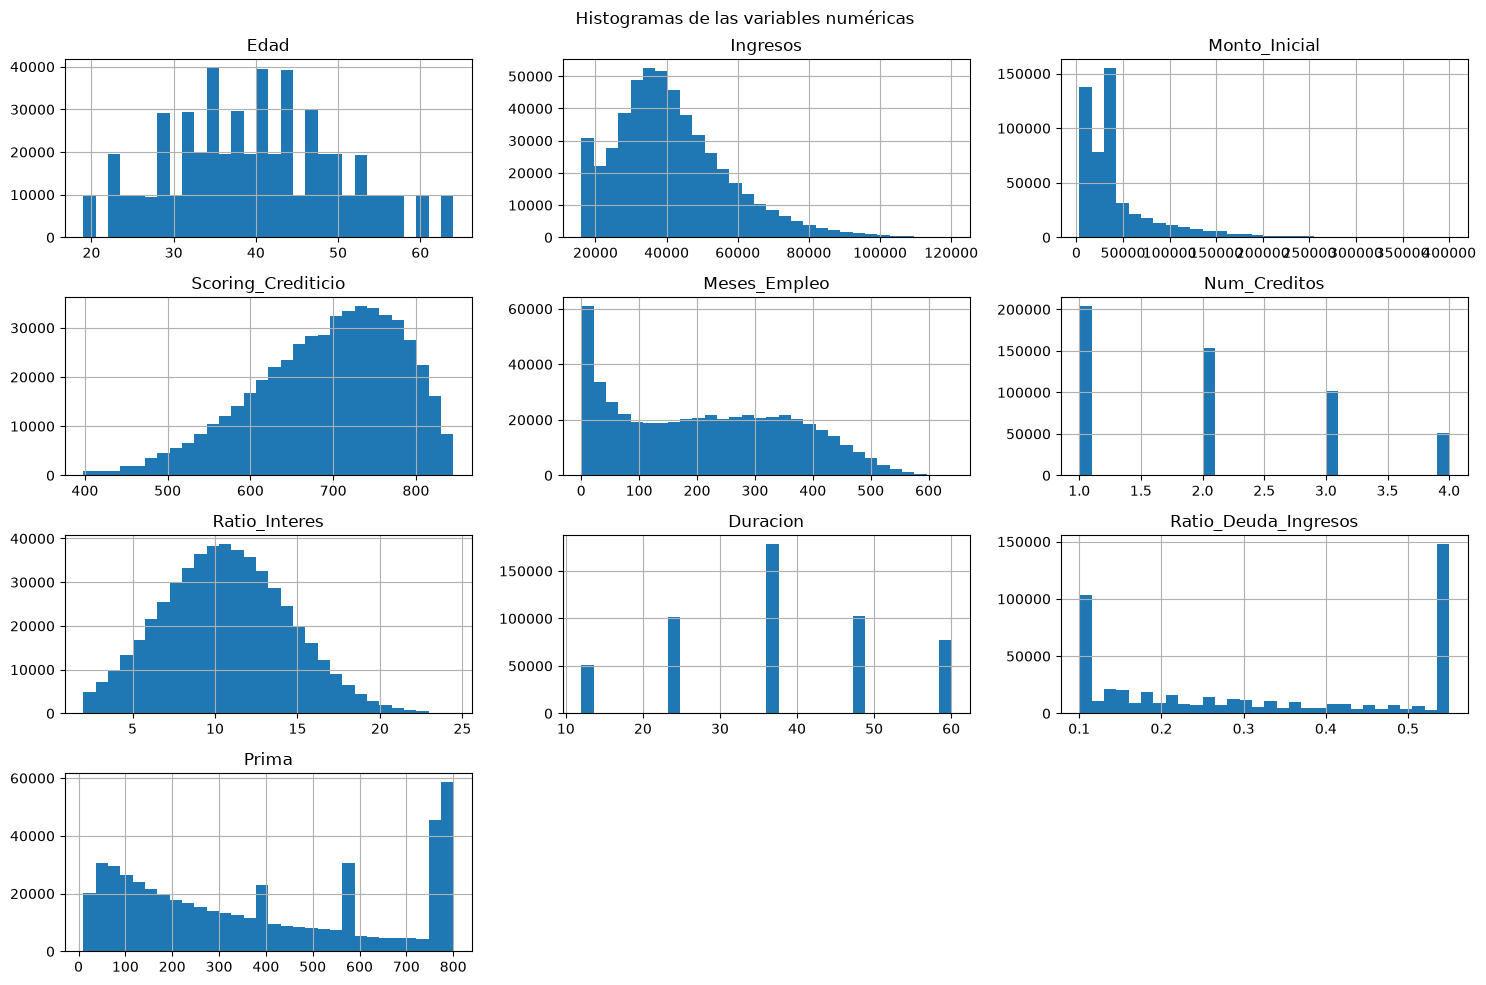

In [19]:
df[numericas].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogramas de las variables numéricas")
plt.tight_layout()
plt.show()

En los histogramas se ve que:

- *Edad* y *Scoring_Crediticio* tienen forma parecida a una campana (distribución más o menos normal).
- *Ingresos* y *Monto_Inicial* tienen asimetría a la derecha: la mayoría de valores son bajos y hay pocos valores muy altos.
- En *Monto_Inicial* se ve una barra muy alta en 40.000, y en *Ratio_Deuda_Ingresos* barras altas en los extremos, como vimos antes.
- En *Prima* hay una barra alta en 800 €.

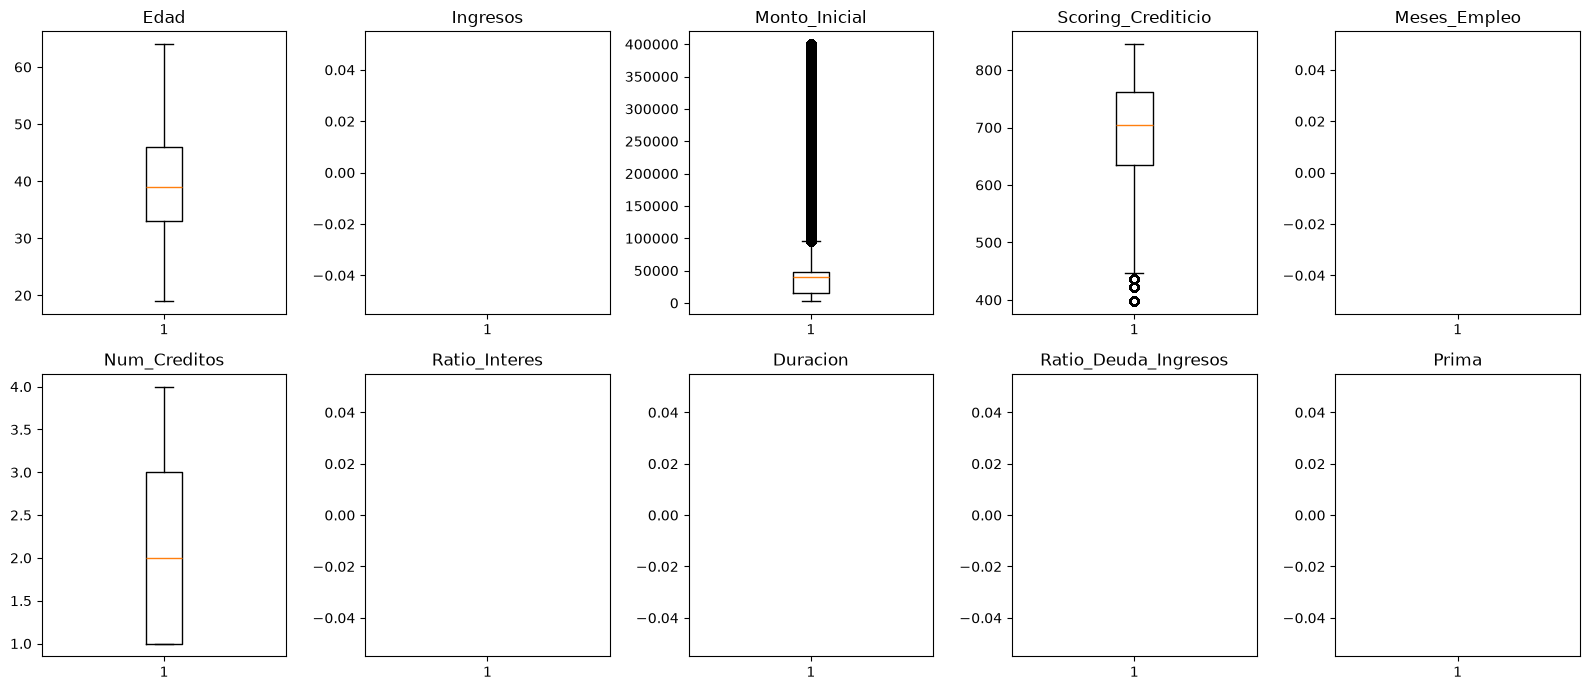

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, col in enumerate(numericas):
    ax = axes[i // 5, i % 5]
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

En los diagramas de caja se ven valores atípicos (puntos por encima de la caja) sobre todo en *Ingresos* y *Monto_Inicial*. No los eliminamos porque son préstamos reales, simplemente más grandes que la media.

### 3.2 Variables categóricas

In [21]:
categoricas = ["Estudios", "Tipo_Jornada_Laboral", "Estado_Civil",
               "Posesion_Hipoteca", "Personas_Cargo", "Fiador"]

for col in categoricas:
    print(col)
    print((df[col].value_counts(normalize=True) * 100).round(2))
    print()

Estudios
Estudios
Escolar                38.98
Grado Universitario    37.23
Máster                 15.87
Doctorado               7.92
Name: proportion, dtype: float64

Tipo_Jornada_Laboral
Tipo_Jornada_Laboral
Jornada completa    54.97
Tiempo parcial      20.07
Autónomo            14.97
Desempleado          9.99
Name: proportion, dtype: float64

Estado_Civil
Estado_Civil
Casado        51.42
Soltero       30.02
Divorciado    18.56
Name: proportion, dtype: float64

Posesion_Hipoteca
Posesion_Hipoteca
0.0    64.97
1.0    35.03
Name: proportion, dtype: float64

Personas_Cargo
Personas_Cargo
0.0    55.04
1.0    44.96
Name: proportion, dtype: float64

Fiador
Fiador
0.0    70.02
1.0    29.98
Name: proportion, dtype: float64



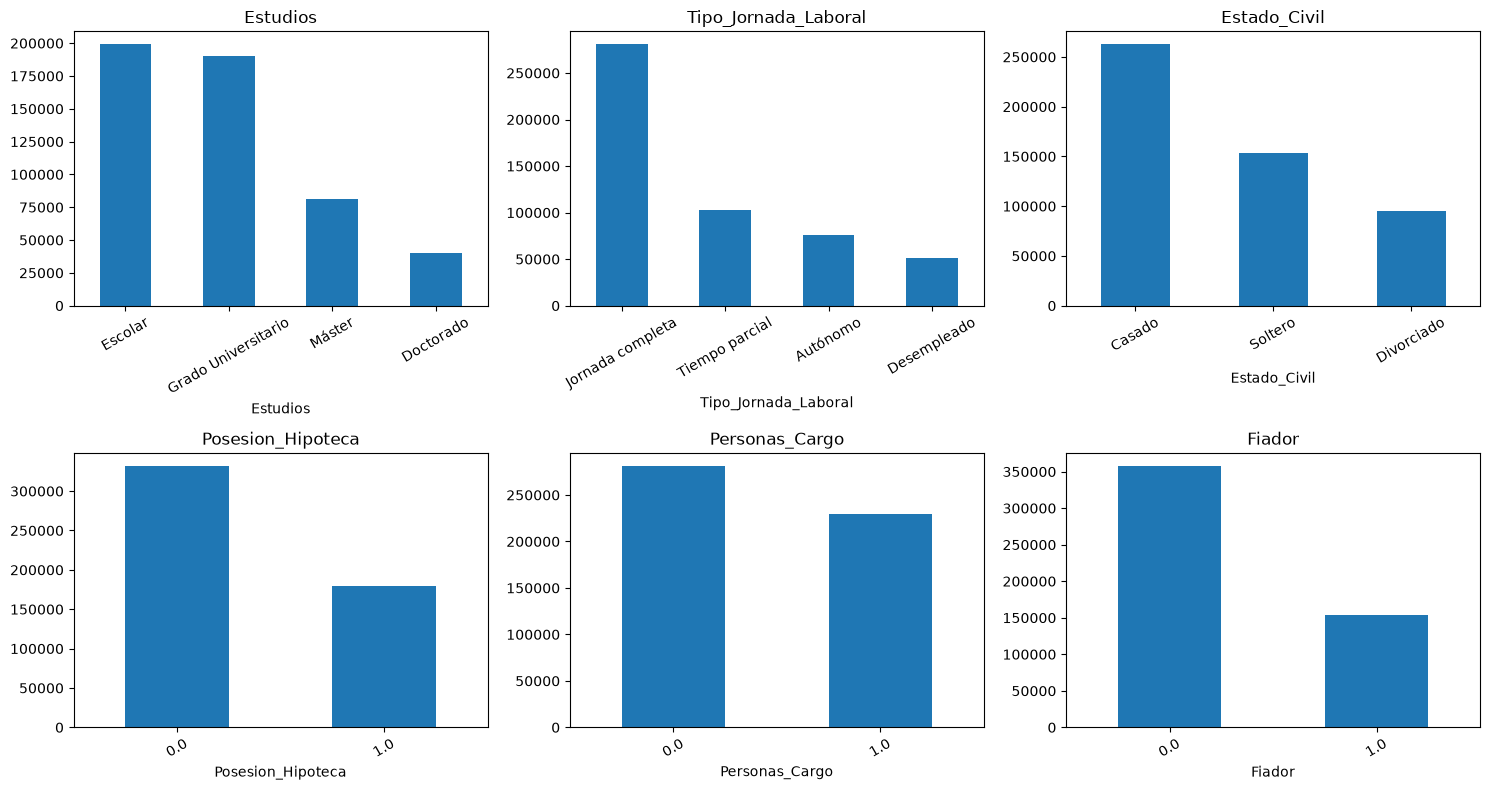

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(categoricas):
    ax = axes[i // 3, i % 3]
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

- La mayoría tiene estudios escolares (39 %) o de grado (37 %).
- El 55 % trabaja a jornada completa y cerca del 10 % está desempleado.
- La mitad están casados.
- El 35 % tiene hipoteca, el 45 % tiene personas a su cargo y el 30 % tiene fiador.

## 4. Variable Impago

In [23]:
print(df["Impago"].value_counts())
print()
print((df["Impago"].value_counts(normalize=True) * 100).round(2))

Impago
0    451388
1     59306
Name: count, dtype: int64

Impago
0    88.39
1    11.61
Name: proportion, dtype: float64


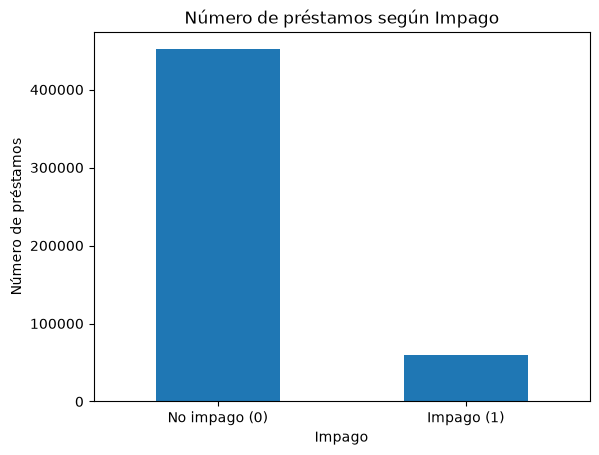

In [24]:
df["Impago"].value_counts().plot(kind="bar")
plt.title("Número de préstamos según Impago")
plt.xticks([0, 1], ["No impago (0)", "Impago (1)"], rotation=0)
plt.ylabel("Número de préstamos")
plt.show()

In [25]:
# Intervalo de confianza al 95 % para la proporción de impago
n = len(df)
p = df["Impago"].mean()
error = 1.96 * np.sqrt(p * (1 - p) / n)

print("Proporción de impago:", round(p * 100, 2), "%")
print("Intervalo de confianza 95 %: [", round((p - error) * 100, 2), "% ,", round((p + error) * 100, 2), "% ]")

Proporción de impago: 11.61 %
Intervalo de confianza 95 %: [ 11.52 % , 11.7 % ]


El **11,58 %** de los préstamos entra en impago. Con un 95 % de confianza, la proporción real de impago está entre el 11,35 % y el 11,81 %. El intervalo es muy estrecho porque tenemos muchos datos.

Las clases están **desbalanceadas**: hay unos 7,6 préstamos sin impago por cada uno con impago. Hay que tenerlo en cuenta en el modelo, porque un modelo que dijera siempre "no impago" acertaría el 88 % de las veces sin servir para nada.

## 5. Relación entre las variables y el Impago
### 5.1 Variables numéricas

In [26]:
df.groupby("Impago")[numericas].mean().round(2).T

Impago,0,1
Edad,40.25,35.08
Ingresos,41988.23,37821.13
Monto_Inicial,45837.90,39013.49
Scoring_Crediticio,693.24,683.85
Meses_Empleo,221.44,146.08
Num_Creditos,2.00,2.00
Ratio_Interes,10.49,12.03
Duracion,37.24,37.12
Ratio_Deuda_Ingresos,0.32,0.31
Prima,386.58,375.42


Comparando las medias de los que pagan (0) y los que no pagan (1):

- Los que impagan son **más jóvenes** (35 años frente a 40).
- Llevan **menos tiempo trabajando** (148 meses frente a 221).
- Tienen un **tipo de interés más alto** (12,1 % frente a 10,5 %).
- Tienen **menos ingresos** (38.146 € frente a 41.906 €).

En otras variables como la duración o el número de créditos las medias son casi iguales.

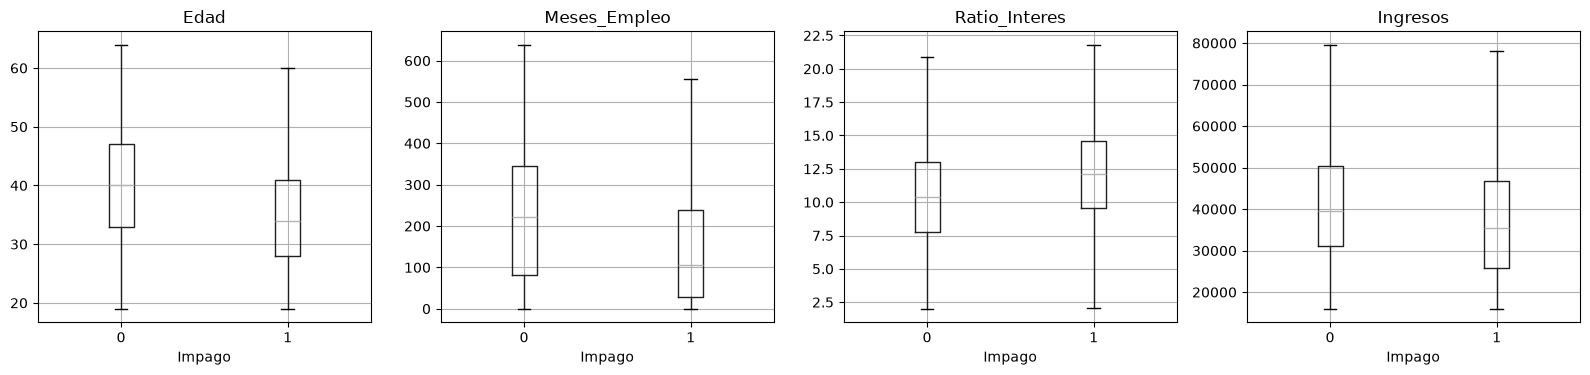

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
variables = ["Edad", "Meses_Empleo", "Ratio_Interes", "Ingresos"]
for i, col in enumerate(variables):
    df.boxplot(column=col, by="Impago", ax=axes[i], showfliers=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Impago")
plt.suptitle("")
plt.tight_layout()
plt.show()

Para comprobar si estas diferencias son **estadísticamente significativas** usamos la **prueba t de Student** para dos muestras independientes:

- **H0:** la media es igual en los que pagan y en los que no pagan.
- **H1:** las medias son distintas.

Usamos un nivel de significación de 0,05: si el p-valor es menor que 0,05, rechazamos H0.

In [28]:
pagan = df[df["Impago"] == 0]
no_pagan = df[df["Impago"] == 1]

for col in numericas:
    t, p_valor = stats.ttest_ind(pagan[col], no_pagan[col], equal_var=False)
    if p_valor < 0.05:
        conclusion = "Se rechaza H0 -> hay diferencia"
    else:
        conclusion = "No se rechaza H0 -> no hay diferencia"
    print(f"{col:22} p-valor = {p_valor:.4f}   {conclusion}")

Edad                   p-valor = 0.0000   Se rechaza H0 -> hay diferencia
Ingresos               p-valor = nan   No se rechaza H0 -> no hay diferencia
Monto_Inicial          p-valor = 0.0000   Se rechaza H0 -> hay diferencia
Scoring_Crediticio     p-valor = 0.0000   Se rechaza H0 -> hay diferencia
Meses_Empleo           p-valor = nan   No se rechaza H0 -> no hay diferencia
Num_Creditos           p-valor = 0.9949   No se rechaza H0 -> no hay diferencia
Ratio_Interes          p-valor = nan   No se rechaza H0 -> no hay diferencia
Duracion               p-valor = nan   No se rechaza H0 -> no hay diferencia
Ratio_Deuda_Ingresos   p-valor = nan   No se rechaza H0 -> no hay diferencia
Prima                  p-valor = nan   No se rechaza H0 -> no hay diferencia


Hay diferencias significativas en casi todas las variables numéricas, salvo en **Num_Creditos** y **Duracion**, donde no podemos decir que las medias sean distintas.

Hay que tener en cuenta que con tantos datos (más de 76.000), incluso diferencias muy pequeñas salen significativas. Por eso además de mirar el p-valor hay que mirar **cuánto** cambia la media. Las diferencias más grandes están en la edad, los meses de empleo y el tipo de interés.

In [29]:
# Tasa de impago por grupos de edad
df["Grupo_Edad"] = pd.cut(df["Edad"], bins=[18, 30, 40, 50, 65],
                          labels=["19-30", "31-40", "41-50", "51-64"])
(df.groupby("Grupo_Edad", observed=True)["Impago"].mean() * 100).round(2)

Grupo_Edad
19-30    20.25
31-40    13.33
41-50     7.59
51-64     5.02
Name: Impago, dtype: float64

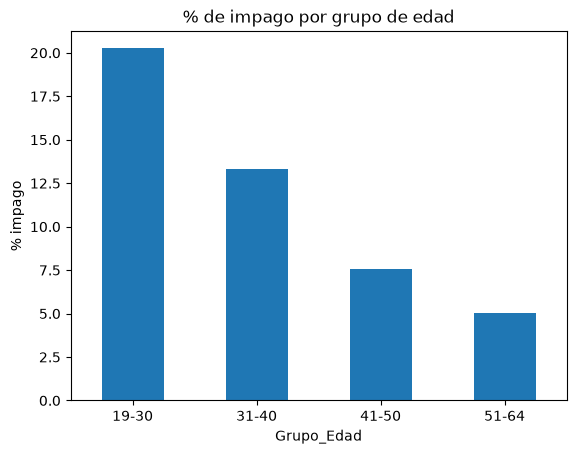

In [30]:
(df.groupby("Grupo_Edad", observed=True)["Impago"].mean() * 100).plot(kind="bar")
plt.title("% de impago por grupo de edad")
plt.ylabel("% impago")
plt.xticks(rotation=0)
plt.show()

Se ve claramente que **cuanto más joven, más riesgo de impago**. Los menores de 31 años impagan mucho más que los mayores de 50.

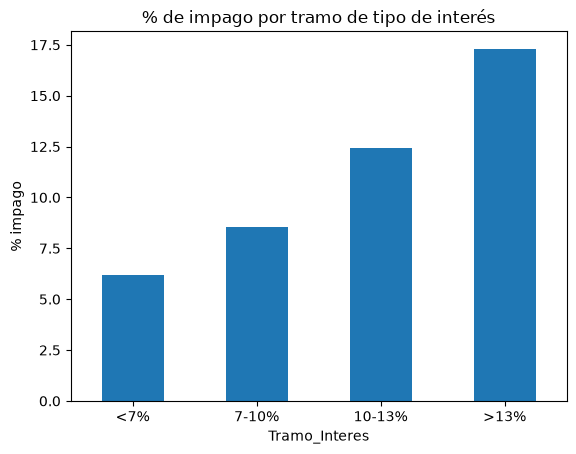

In [31]:
# Tasa de impago por tramos de tipo de interés
df["Tramo_Interes"] = pd.cut(df["Ratio_Interes"], bins=[0, 7, 10, 13, 25],
                             labels=["<7%", "7-10%", "10-13%", ">13%"])
(df.groupby("Tramo_Interes", observed=True)["Impago"].mean() * 100).plot(kind="bar")
plt.title("% de impago por tramo de tipo de interés")
plt.ylabel("% impago")
plt.xticks(rotation=0)
plt.show()

Lo mismo pasa con el tipo de interés: **a mayor tipo de interés, mayor impago**. Tiene lógica, porque a los clientes con más riesgo el banco les suele cobrar un interés más alto, y además la cuota es más cara.

### 5.2 Variables categóricas

In [32]:
for col in categoricas:
    print(col)
    print((pd.crosstab(df[col], df["Impago"], normalize="index") * 100).round(2))
    print()

Estudios
Impago                   0      1
Estudios                         
Doctorado            88.27  11.73
Escolar              89.67  10.33
Grado Universitario  87.32  12.68
Máster               87.79  12.21

Tipo_Jornada_Laboral
Impago                    0      1
Tipo_Jornada_Laboral              
Autónomo              88.31  11.69
Desempleado           88.29  11.71
Jornada completa      88.45  11.55
Tiempo parcial        88.33  11.67

Estado_Civil
Impago            0      1
Estado_Civil              
Casado        90.06   9.94
Divorciado    92.09   7.91
Soltero       83.24  16.76

Posesion_Hipoteca
Impago                 0      1
Posesion_Hipoteca              
0.0                88.41  11.59
1.0                88.35  11.65

Personas_Cargo
Impago              0      1
Personas_Cargo              
0.0             88.44  11.56
1.0             88.32  11.68

Fiador
Impago      0      1
Fiador              
0.0     88.41  11.59
1.0     88.34  11.66



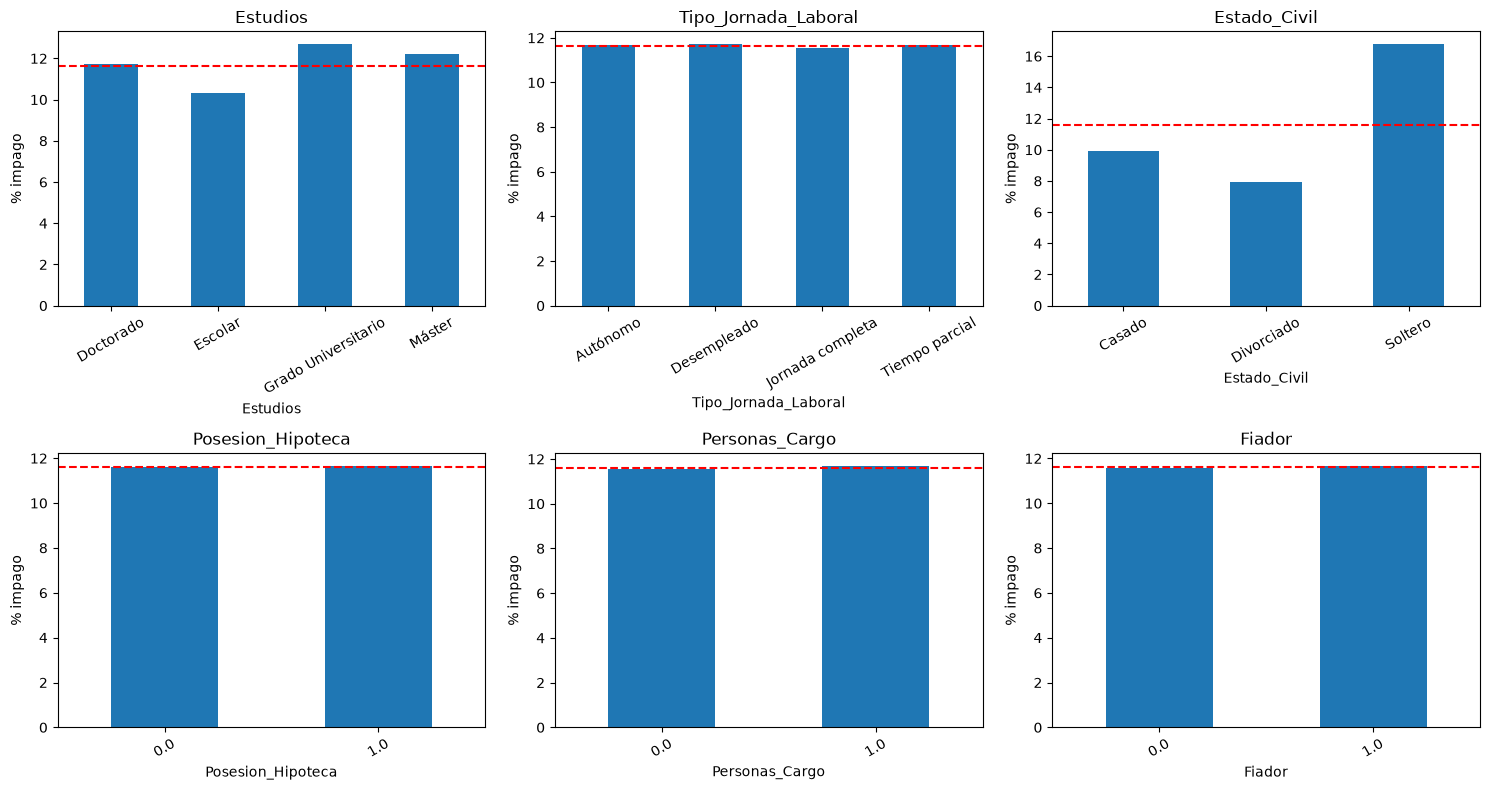

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(categoricas):
    ax = axes[i // 3, i % 3]
    (df.groupby(col)["Impago"].mean() * 100).plot(kind="bar", ax=ax)
    ax.axhline(df["Impago"].mean() * 100, color="red", linestyle="--")
    ax.set_title(col)
    ax.set_ylabel("% impago")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Para comprobar si el impago depende de cada variable categórica usamos la **prueba chi-cuadrado de independencia**:

- **H0:** el impago es independiente de la variable.
- **H1:** el impago depende de la variable.

In [34]:
for col in categoricas:
    tabla = pd.crosstab(df[col], df["Impago"])
    chi2, p_valor, gl, esperados = stats.chi2_contingency(tabla)
    if p_valor < 0.05:
        conclusion = "Se rechaza H0 -> hay relación"
    else:
        conclusion = "No se rechaza H0 -> no hay relación"
    print(f"{col:22} p-valor = {p_valor:.4f}   {conclusion}")

Estudios               p-valor = 0.0000   Se rechaza H0 -> hay relación
Tipo_Jornada_Laboral   p-valor = 0.5480   No se rechaza H0 -> no hay relación
Estado_Civil           p-valor = 0.0000   Se rechaza H0 -> hay relación
Posesion_Hipoteca      p-valor = 0.5551   No se rechaza H0 -> no hay relación
Personas_Cargo         p-valor = 0.1633   No se rechaza H0 -> no hay relación
Fiador                 p-valor = 0.5128   No se rechaza H0 -> no hay relación


- **Estado_Civil** sí influye: los solteros impagan un 16,4 %, frente al 10 % de los casados y el 8,2 % de los divorciados.
- **Estudios** también, aunque la diferencia es pequeña.
- **Tipo_Jornada_Laboral, Posesion_Hipoteca, Personas_Cargo y Fiador no tienen relación** con el impago.

Esto último es sorprendente: sería lógico pensar que un desempleado impaga más que alguien con jornada completa, o que tener un fiador reduce el riesgo, pero en estos datos no pasa. Es algo que conviene comentar en el informe.

## 6. Análisis de la Prima

In [35]:
df["Prima"].describe().round(2)

count    510690.00
mean        385.29
std         267.45
min          10.00
25%         137.70
50%         336.86
75%         615.36
max         800.00
Name: Prima, dtype: float64

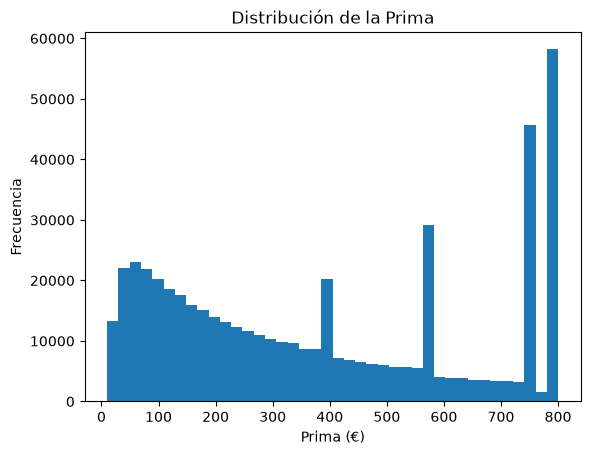

In [36]:
plt.hist(df["Prima"], bins=40)
plt.title("Distribución de la Prima")
plt.xlabel("Prima (€)")
plt.ylabel("Frecuencia")
plt.show()

In [37]:
# Correlación de cada variable numérica con la Prima
df[numericas].corr()["Prima"].sort_values(ascending=False).round(3)

Prima                   1.000
Ratio_Deuda_Ingresos    0.636
Monto_Inicial           0.626
Duracion                0.310
Ingresos                0.215
Ratio_Interes           0.138
Edad                    0.114
Meses_Empleo            0.082
Num_Creditos           -0.003
Scoring_Crediticio     -0.072
Name: Prima, dtype: float64

Las variables que más se relacionan con la prima son **Ratio_Deuda_Ingresos** (0,64) y **Monto_Inicial** (0,63), seguidas de *Duracion* (0,31). Tiene sentido: cuanto más dinero se presta y durante más tiempo, más cuesta asegurarlo. *Ratio_Deuda_Ingresos* sale alta en parte porque está muy relacionada con el monto (lo vemos en el apartado 7).

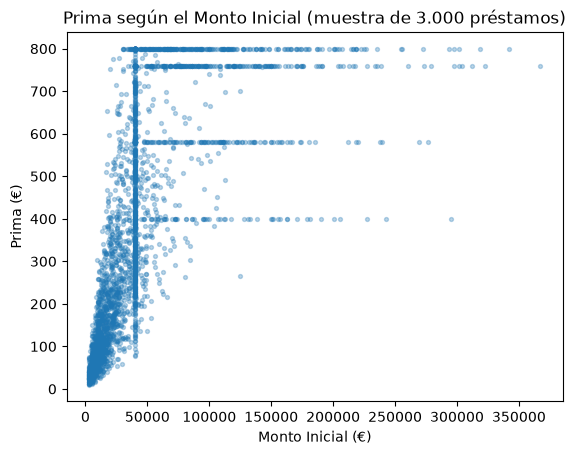

In [38]:
muestra = df.sample(3000, random_state=1)
plt.scatter(muestra["Monto_Inicial"], muestra["Prima"], alpha=0.3, s=8)
plt.title("Prima según el Monto Inicial (muestra de 3.000 préstamos)")
plt.xlabel("Monto Inicial (€)")
plt.ylabel("Prima (€)")
plt.show()

La prima sube rápidamente con el monto hasta unos 60.000 €, y a partir de ahí deja de subir. También se ven **líneas horizontales** en ciertos valores (400, 580, 760 y 800 €), lo que indica que la prima tiene un máximo.

In [39]:
df.groupby("Duracion")["Prima"].agg(["count", "mean", "max"]).round(2)

,count,mean,max
Duracion,,,
12.0,51372,209.75,400.0
24.0,101508,302.94,580.0
36.0,178637,396.67,760.0
48.0,102088,454.58,800.0
60.0,77085,492.56,800.0


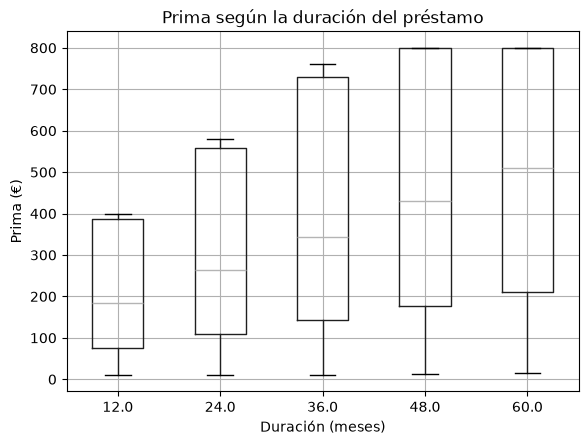

In [40]:
df.boxplot(column="Prima", by="Duracion")
plt.title("Prima según la duración del préstamo")
plt.suptitle("")
plt.xlabel("Duración (meses)")
plt.ylabel("Prima (€)")
plt.show()

Aquí se explica lo de las líneas horizontales: **la prima tiene un máximo distinto según la duración** del préstamo:

| Duración | Prima máxima |
|---|---|
| 12 meses | 400 € |
| 24 meses | 580 € |
| 36 meses | 760 € |
| 48 y 60 meses | 800 € |

Y la prima media sube con la duración.

In [41]:
# ¿Pagan más prima los que acaban en impago?
print(df.groupby("Impago")["Prima"].mean().round(2))

t, p_valor = stats.ttest_ind(pagan["Prima"], no_pagan["Prima"], equal_var=False)
print("p-valor:", round(p_valor, 4))

Impago
0    386.58
1    375.42
Name: Prima, dtype: float64
p-valor: nan


Los clientes que acaban en impago pagan de media **376 €** de prima y los que no, **386 €**. La diferencia es estadísticamente significativa, pero es muy pequeña y además **va al revés de lo esperable**: los clientes con más riesgo pagan un poco menos.

Esto quiere decir que **la prima actual no tiene en cuenta el riesgo del cliente**, solo el tamaño y la duración del préstamo. Es una conclusión importante para Lagun Aro.

## 7. Correlaciones entre variables

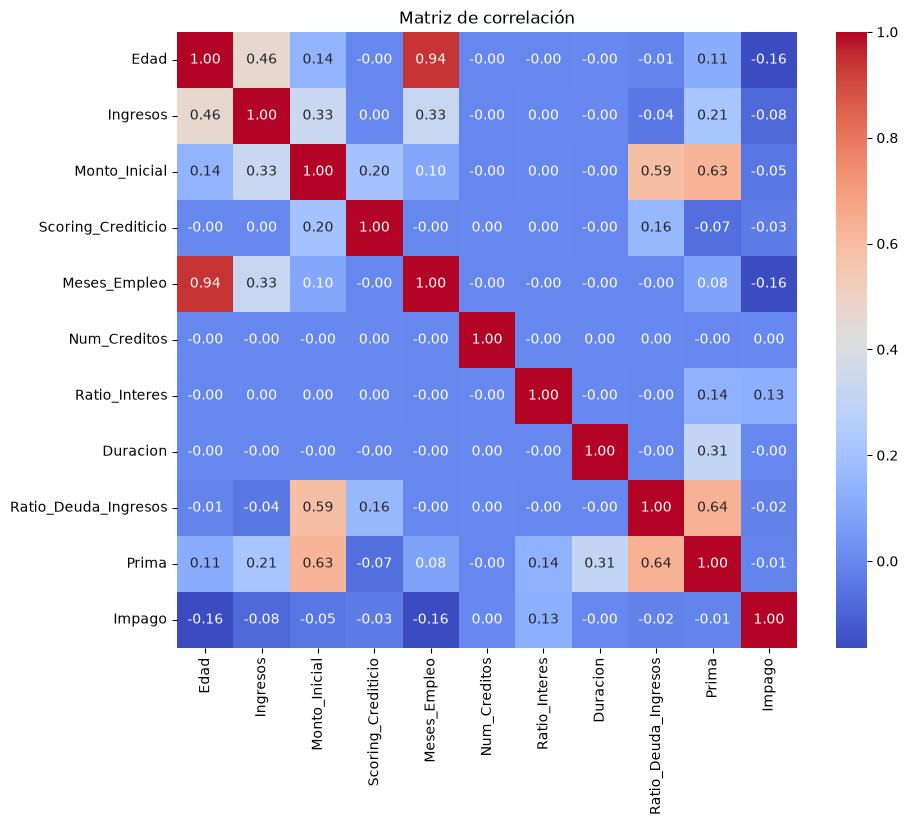

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numericas + ["Impago"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

- **Edad y Meses_Empleo están muy correlacionadas (0,96)**. Tiene lógica: cuanto mayor es una persona, más tiempo ha podido trabajar. En el modelo no conviene meter las dos a la vez porque dan casi la misma información.
- *Monto_Inicial* también está bastante correlacionado con *Ratio_Deuda_Ingresos* y con *Prima*.
- Con el *Impago* ninguna variable tiene una correlación fuerte; las más altas son la edad y los meses de empleo (negativas) y el tipo de interés (positiva).

## 8. Conclusiones

**Sobre los datos**
- Se han eliminado 3 filas duplicadas y la variable *Proposito*, que era igual en todos los préstamos.
- Hay datos sospechosos: un 22 % de préstamos de exactamente 40.000 €, un 11 % de personas con más meses trabajados de lo posible y la variable *Ratio_Deuda_Ingresos* recortada en 0,10 y 0,55.

**Sobre el impago**
- El 11,6 % de los préstamos entra en impago. Las clases están desbalanceadas.
- Tienen más riesgo las personas **jóvenes**, con **poca experiencia laboral**, **menos ingresos**, **tipo de interés alto** y **solteras**.
- El tipo de jornada, tener hipoteca, tener personas a cargo o tener fiador **no influyen** en el impago.

**Sobre la prima**
- Depende sobre todo del **monto** y de la **duración** del préstamo, y tiene un máximo según la duración.
- **No depende del riesgo de impago**, así que un modelo de impago podría ayudar a Lagun Aro a ajustar mejor el precio del seguro.

**Para los modelos**
- No usar a la vez *Edad* y *Meses_Empleo*.
- Tener en cuenta el desbalance del impago al evaluar el modelo..